# Clasificación de imágenes satelitales con **Shepherd Segmentation** — local (stack pip)
### Versión con descarga desde Google Drive + **reportes de ejecución** (fase de desarrollo)

Reconstrucción del cuaderno *Semana 14* para correr **localmente** (JupyterLab / venv / `uv`), **sin Conda, sin RSGISLib, sin formato KEA, sin TPOT**.

Segmentación = **Shepherd et al. (2019)** vía `pyshepseg`, igual que tu pipeline `geocrop_analysis_mx`, para que sirva de plantilla al cuaderno de **cultivos**.

**Novedad de esta versión:** cada fase registra diagnósticos en un acumulador `REPORT`, y la **Fase 8** escribe un reporte legible (`reporte_ejecucion.md`), uno estructurado (`reporte_ejecucion.json`) y las figuras (matriz de confusión y mapa). Esos archivos son los que me subes para revisar.

**Productos:** `segments.gpkg`, `features_sentinel_urbano.csv`, `clasificacion_urbano.gpkg`, `reporte_ejecucion.{md,json}`, `matriz_confusion.png`, `mapa_clasificacion.png`.

## 0. Instalación

> `pyshepseg` **no está en PyPI** (solo conda-forge); se instala desde GitHub. `gdown` se agrega solo para bajar de Google Drive. El resto trae sus binarios (GDAL/GEOS/PROJ/LLVM) en las *wheels*.

In [5]:
%pip install gdown

  Using cached filelock-3.29.1-py3-none-any.whl.metadata (2.0 kB)
  Using cached tqdm-4.68.2-py3-none-any.whl.metadata (58 kB)
Using cached filelock-3.29.1-py3-none-any.whl (40 kB)
Using cached tqdm-4.68.2-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [gdown]32m2/4 [filelock]
Note: you may need to restart the kernel to use updated packages.


## 1. Imports, configuración y acumulador de reporte

`REPORT` recoge los diagnósticos de cada fase; al final se vuelca a disco.

In [2]:
import os, sys, json, time, platform, zipfile
from datetime import datetime
import numpy as np
import pandas as pd
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.ops import unary_union
from pyshepseg import shepseg
from exactextract import exact_extract
import matplotlib.pyplot as plt

CFG = {
    # --- IDs de Google Drive (de tu cuaderno original) ---
    "drive_ids": {
        "GM_AGS_2020.tif": "1JTlU6M2Kt2kpkPOsDmmsCVrT7m1RApAX",
        "00l.gpkg":        "1J03WNpnqH38hWZfAlheHFmvKdDnsoJSN",
        "limite_ags.zip":  "1K4Cn2-HHDxfvb9YBdFfS8zGUOjbGPK50",
    },
    # --- Entradas (rutas locales tras la descarga) ---
    "geomediana":     "GM_AGS_2020.tif",
    "localidades":    "00l.gpkg",
    "limite_zip":     "limite_ags.zip",
    "limite_dir":     "limite_ags",
    "limite_ags":     None,   # se resuelve tras descomprimir (busca el .shp)
    # --- Salidas ---
    "segmentos_tif":  "segments.tif",
    "segmentos_gpkg": "segments.gpkg",
    "etiquetas_tif":  "Etiquetas_1_urbano_2_no_urbano.tif",
    "features_csv":   "features_sentinel_urbano.csv",
    "clasif_gpkg":    "clasificacion_urbano.gpkg",
    "reporte_md":     "reporte_ejecucion.md",
    "reporte_json":   "reporte_ejecucion.json",
    "fig_cm":         "matriz_confusion.png",
    "fig_mapa":       "mapa_clasificacion.png",
    # --- Parámetros Shepherd ---
    "num_clusters":     60,
    "min_segment_size": 100,
    "n_bandas":         12,
}

REPORT = {
    "generado": datetime.now().isoformat(timespec="seconds"),
    "entorno": {"python": sys.version.split()[0], "plataforma": platform.platform(),
                "numpy": np.__version__, "pandas": pd.__version__,
                "rasterio": rasterio.__version__, "geopandas": gpd.__version__},
    "config": {k: v for k, v in CFG.items() if k != "drive_ids"},
    "fases": {},
}
def log_fase(nombre, **datos):
    REPORT["fases"][nombre] = {"ts": datetime.now().isoformat(timespec="seconds"), **datos}
    print(f"[REPORT] {nombre}: {datos}")

print("Config y acumulador REPORT listos.")

Config y acumulador REPORT listos.


## 2. Fase 0 — Descarga de datos (Google Drive)

Baja la geomediana, las localidades INEGI y el límite del AOI por su ID de Drive. Si los archivos ya existen, no se vuelven a bajar. Se descomprime el límite y se localiza el `.shp`.

In [6]:
import gdown
t0 = time.perf_counter()

for nombre, fid in CFG["drive_ids"].items():
    if os.path.exists(nombre):
        print(f"  ya existe: {nombre}")
    else:
        print(f"  descargando {nombre} ...")
        gdown.download(id=fid, output=nombre, quiet=False)

# Descomprimir el límite y localizar el shapefile
if os.path.exists(CFG["limite_zip"]):
    with zipfile.ZipFile(CFG["limite_zip"]) as z:
        z.extractall(CFG["limite_dir"])
shp = [os.path.join(r, f) for r, _, fs in os.walk(CFG["limite_dir"]) for f in fs if f.lower().endswith(".shp")]
CFG["limite_ags"] = shp[0] if shp else None
print("Límite (.shp):", CFG["limite_ags"])

# Tamaños descargados (diagnóstico de desarrollo)
tam = {n: round(os.path.getsize(n)/1e6, 1) for n in CFG["drive_ids"] if os.path.exists(n)}
log_fase("fase0_descarga", archivos_MB=tam, limite_shp=CFG["limite_ags"],
         segundos=round(time.perf_counter()-t0, 1))

  descargando GM_AGS_2020.tif ...


Downloading...
From (original): https://drive.google.com/uc?id=1JTlU6M2Kt2kpkPOsDmmsCVrT7m1RApAX
From (redirected): https://drive.google.com/uc?id=1JTlU6M2Kt2kpkPOsDmmsCVrT7m1RApAX&confirm=t&uuid=9aaeeb78-9e44-4423-b291-722ee1ab32d3
To: /mnt/data_4tb/SatLab/notebooks/GM_AGS_2020.tif
100%|██████████| 2.66G/2.66G [00:51<00:00, 52.1MB/s]


  descargando 00l.gpkg ...


Downloading...
From (original): https://drive.google.com/uc?id=1J03WNpnqH38hWZfAlheHFmvKdDnsoJSN
From (redirected): https://drive.google.com/uc?id=1J03WNpnqH38hWZfAlheHFmvKdDnsoJSN&confirm=t&uuid=e49f8b61-90c2-4c41-b19c-98a61baaae8f
To: /mnt/data_4tb/SatLab/notebooks/00l.gpkg
100%|██████████| 110M/110M [00:02<00:00, 43.9MB/s] 


  descargando limite_ags.zip ...


Downloading...
From: https://drive.google.com/uc?id=1K4Cn2-HHDxfvb9YBdFfS8zGUOjbGPK50
To: /mnt/data_4tb/SatLab/notebooks/limite_ags.zip
100%|██████████| 1.50k/1.50k [00:00<00:00, 2.77MB/s]

Límite (.shp): limite_ags/Region_Aguascalientes.shp
[REPORT] fase0_descarga: {'archivos_MB': {'GM_AGS_2020.tif': 2662.1, '00l.gpkg': 110.4, 'limite_ags.zip': 0.0}, 'limite_shp': 'limite_ags/Region_Aguascalientes.shp', 'segundos': 59.7}


## 3. Fase 1 — Segmentación Shepherd

`doShepherdSegmentation` recibe `(bandas, filas, columnas)` y devuelve `segimg` (`uint32`, 0 = nulo). Poligonizamos con `rasterio.features.shapes` (reemplazo de la poligonización KEA de RSGISLib) y guardamos `segments.gpkg`.

> Si la geomediana es la estatal completa y tarda demasiado, define un AOI recortando `img` antes de segmentar (y recorta `transform` en consecuencia).

In [7]:
t0 = time.perf_counter()
with rasterio.open(CFG["geomediana"]) as src:
    img = src.read()
    transform, crs, nodata = src.transform, src.crs, src.nodata
    geom_shape = (src.height, src.width)

seg_res = shepseg.doShepherdSegmentation(
    img, numClusters=CFG["num_clusters"],
    minSegmentSize=CFG["min_segment_size"], imgNullVal=nodata)
seg = seg_res.segimg.astype(np.int32)

meta = {"driver":"GTiff","height":seg.shape[0],"width":seg.shape[1],
        "count":1,"dtype":"int32","crs":crs,"transform":transform}
with rasterio.open(CFG["segmentos_tif"], "w", **meta) as dst:
    dst.write(seg, 1)

geoms = ({"properties":{"segment_id":int(v)}, "geometry":g}
         for g, v in features.shapes(seg, transform=transform) if v != 0)
gdf_seg = gpd.GeoDataFrame.from_features(geoms, crs=crs).dissolve(by="segment_id", as_index=False)
gdf_seg.to_file(CFG["segmentos_gpkg"], driver="GPKG")

log_fase("fase1_segmentacion",
         dims=list(geom_shape), bandas=int(img.shape[0]),
         n_segmentos=int(seg.max()), n_poligonos=len(gdf_seg),
         pequenos_eliminados=int(seg_res.smallSegmentsEliminated),
         crs=str(crs), segundos=round(time.perf_counter()-t0, 1))

[REPORT] fase1_segmentacion: {'dims': [10005, 11086], 'bandas': 12, 'n_segmentos': 445486, 'n_poligonos': 445486, 'pequenos_eliminados': 7623366, 'crs': 'PROJCS["unknown",GEOGCS["unknown",DATUM["Unknown_based_on_GRS80_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",12],PARAMETER["longitude_of_center",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]', 'segundos': 130.8}


## 4. Fase 2 — Ráster de etiquetas (urbano / no-urbano)

Localidades INEGI (`AMBITO` ∈ {Urbana, Rural} → urbana = 1), resto del AOI = 2, *quemadas* a un GeoTIFF alineado con la geomediana. Sin el hack `PROJ_LIB` de Conda.

In [8]:
t0 = time.perf_counter()
with rasterio.open(CFG["geomediana"]) as src:
    crs_ref, transform_ref, W, H = src.crs, src.transform, src.width, src.height

gdf_lim = gpd.read_file(CFG["limite_ags"])
if gdf_lim.crs != crs_ref: gdf_lim = gdf_lim.to_crs(crs_ref)
geom_lim = unary_union(gdf_lim.geometry)
if not geom_lim.is_valid: geom_lim = geom_lim.buffer(0)

gdf_loc = gpd.read_file(CFG["localidades"])
if gdf_loc.crs != crs_ref: gdf_loc = gdf_loc.to_crs(crs_ref)
gdf_loc = gdf_loc[gdf_loc.intersects(geom_lim)].copy()

urb = gdf_loc[gdf_loc["AMBITO"].isin(["Urbana", "Rural"])]
geom_urb = unary_union(urb.geometry).intersection(geom_lim)
if not geom_urb.is_valid: geom_urb = geom_urb.buffer(0)
geom_nourb = geom_lim.difference(geom_urb)

labels = features.rasterize([(geom_nourb, 2), (geom_urb, 1)], out_shape=(H, W),
                            transform=transform_ref, fill=0, dtype="int32")
with rasterio.open(CFG["etiquetas_tif"], "w", driver="GTiff", height=H, width=W,
                   count=1, dtype="int32", crs=crs_ref, transform=transform_ref, nodata=0) as dst:
    dst.write(labels, 1)

log_fase("fase2_etiquetas",
         localidades_en_AOI=int(len(gdf_loc)),
         px_urbano=int((labels==1).sum()), px_no_urbano=int((labels==2).sum()),
         px_fondo=int((labels==0).sum()), segundos=round(time.perf_counter()-t0, 1))

[REPORT] fase2_etiquetas: {'localidades_en_AOI': 610, 'px_urbano': 3688912, 'px_no_urbano': 107226518, 'px_fondo': 0, 'segundos': 4.7}


## 5. Fase 3 — Proporción de clase por segmento

Reemplazo de `populate_rat_with_cat_proportions`. `segimg` y etiquetas están alineados píxel a píxel → proporción exacta con `np.bincount`.

In [9]:
t0 = time.perf_counter()
with rasterio.open(CFG["etiquetas_tif"]) as src:
    lab = src.read(1).astype(np.int64)
seg64 = seg.astype(np.int64); nseg = int(seg64.max()) + 1

total = np.bincount(seg64.ravel(), minlength=nseg)
cnt1  = np.bincount(seg64.ravel(), weights=(lab==1).ravel(), minlength=nseg)
cnt2  = np.bincount(seg64.ravel(), weights=(lab==2).ravel(), minlength=nseg)
with np.errstate(invalid="ignore"):
    prop1 = np.where(total>0, cnt1/total, 0.0)
    prop2 = np.where(total>0, cnt2/total, 0.0)
klass = np.where(prop1>=prop2, 1, 2)

df_prop = pd.DataFrame({"segment_id":np.arange(nseg), "klass":klass,
                        "klass__1":prop1, "klass__2":prop2})
df_prop = df_prop[df_prop.segment_id>0].reset_index(drop=True)

log_fase("fase3_proporciones",
         segmentos=int(len(df_prop)),
         mayoria_urbano=int((df_prop.klass==1).sum()),
         mayoria_no_urbano=int((df_prop.klass==2).sum()),
         segundos=round(time.perf_counter()-t0, 1))
df_prop.head()

[REPORT] fase3_proporciones: {'segmentos': 445486, 'mayoria_urbano': 18222, 'mayoria_no_urbano': 427264, 'segundos': 1.2}


,segment_id,klass,klass__1,klass__2
0,1,2,0.000000,1.000000
1,2,2,0.061321,0.938679
2,3,2,0.239401,0.760599
3,4,2,0.000000,1.000000
4,5,2,0.000000,1.000000


## 6. Fase 4 — Estadísticas espectrales por segmento (`exactextract`)

Reemplazo de `populate_rat_with_stats`. `exact_extract(..., output="pandas")` → columnas `band_N_stat`, renombradas a `b{N}{Stat}`.

In [10]:
t0 = time.perf_counter()
STATS = ["min", "max", "mean", "stdev", "sum"]
df_stats = exact_extract(CFG["geomediana"], gdf_seg, STATS, output="pandas")

nice = {"min":"Min","max":"Max","mean":"Mean","stdev":"StdDev","sum":"Sum"}
rename = {f"band_{b}_{s}": f"b{b}{nice[s]}" for b in range(1, CFG["n_bandas"]+1) for s in STATS}
df_stats = df_stats.rename(columns=rename)
df_stats["segment_id"] = gdf_seg["segment_id"].values

log_fase("fase4_estadisticas",
         segmentos=int(df_stats.shape[0]),
         n_features=int(df_stats.shape[1]-1),
         estadisticas=STATS, segundos=round(time.perf_counter()-t0, 1))
df_stats.filter(regex='^b1').head()

[REPORT] fase4_estadisticas: {'segmentos': 445486, 'n_features': 60, 'estadisticas': ['min', 'max', 'mean', 'stdev', 'sum'], 'segundos': 797.6}


,b1Min,b10Min,b11Min,b12Min,b1Max,b10Max,b11Max,b12Max,b1Mean,b10Mean,b11Mean,b12Mean,b1StdDev,b10StdDev,b11StdDev,b12StdDev,b1Sum,b10Sum,b11Sum,b12Sum
0,353,2846,3860,3088,439,2962,4025,3303,396.627451,2902.980392,3938.954248,3164.222222,18.265251,31.432565,43.782191,45.988237,60684.0,444156.0,602660.0,484126.0
1,389,2870,3458,2795,637,3153,4305,3471,445.174528,3016.294811,4006.759434,3182.705189,42.487931,61.448804,100.381941,86.091057,377508.0,2557818.0,3397732.0,2698934.0
2,398,2672,3343,2589,516,3028,4069,3279,443.561097,2801.705736,3786.947631,3013.014963,25.781005,65.040085,157.628085,137.030203,177868.0,1123484.0,1518566.0,1208219.0
3,306,2662,3084,2240,493,2961,4002,3164,401.049844,2831.473520,3624.467290,2814.264798,37.783001,75.121501,133.241704,148.939433,128737.0,908903.0,1163454.0,903379.0
4,178,2846,2718,1798,290,3352,3192,2259,217.557971,3088.630435,2889.471014,2014.797101,33.851341,122.047809,128.050725,142.435043,30023.0,426231.0,398747.0,278042.0


## 7. Fase 5 — Tabla final → CSV (reemplazo de `export_rat_cols_to_ascii`)

In [11]:
features_df = df_prop.merge(df_stats, on="segment_id", how="inner")
features_df.to_csv(CFG["features_csv"], index=False)
log_fase("fase5_csv", filas=int(features_df.shape[0]), columnas=int(features_df.shape[1]),
         archivo=CFG["features_csv"])
features_df.head()

[REPORT] fase5_csv: {'filas': 445486, 'columnas': 64, 'archivo': 'features_sentinel_urbano.csv'}


,segment_id,klass,klass__1,klass__2,b1Min,b2Min,b3Min,b4Min,b5Min,b6Min,...,b3Sum,b4Sum,b5Sum,b6Sum,b7Sum,b8Sum,b9Sum,b10Sum,b11Sum,b12Sum
0,1,2,0.000000,1.000000,353,657,1106,1644,2136,2413,...,191231.0,297026.0,344208.0,386562.0,413661.0,448392.0,450584.0,444156.0,602660.0,484126.0
1,2,2,0.061321,0.938679,389,556,959,1397,1931,2322,...,1098367.0,1642831.0,1922747.0,2183369.0,2347146.0,2549174.0,2570579.0,2557818.0,3397732.0,2698934.0
2,3,2,0.239401,0.760599,398,488,871,1185,1619,2022,...,484552.0,677085.0,804008.0,933455.0,1010794.0,1104889.0,1122149.0,1123484.0,1518566.0,1208219.0
3,4,2,0.000000,1.000000,306,422,804,1036,1488,2014,...,375731.0,519856.0,630120.0,759352.0,825405.0,900380.0,913004.0,908903.0,1163454.0,903379.0
4,5,2,0.000000,1.000000,178,300,714,807,1415,2350,...,110843.0,142306.0,214583.0,357665.0,399626.0,430900.0,434626.0,426231.0,398747.0,278042.0


## 8. Fase 6 — Clasificación (sklearn puro, sin TPOT)

`StackingEstimator` reimplementado en sklearn puro. Balanceo con celdas "puras" (≥90 %). Las métricas se guardan en `REPORT` y la matriz de confusión como figura.

              precision    recall  f1-score   support

           1     0.9498    0.9318    0.9407      4427
           2     0.9331    0.9508    0.9418      4427

    accuracy                         0.9413      8854
   macro avg     0.9414    0.9413    0.9413      8854
weighted avg     0.9414    0.9413    0.9413      8854



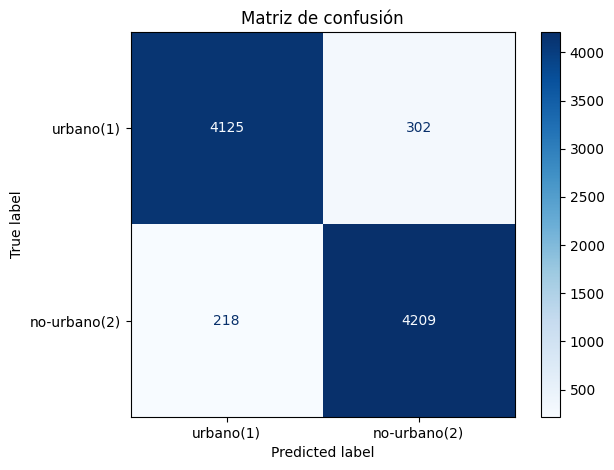

[REPORT] fase6_clasificacion: {'n_entrenamiento': 20658, 'n_prueba': 8854, 'accuracy': 0.9413, 'f1_urbano': 0.9407, 'f1_no_urbano': 0.9418, 'matriz_confusion': [[4125, 302], [218, 4209]], 'reporte_sklearn': {'1': {'precision': 0.9498042827538568, 'recall': 0.9317822453128529, 'f1-score': 0.9407069555302167, 'support': 4427.0}, '2': {'precision': 0.9330525382398581, 'recall': 0.9507567201264965, 'f1-score': 0.9418214365629894, 'support': 4427.0}, 'accuracy': 0.9412694827196747, 'macro avg': {'precision': 0.9414284104968574, 'recall': 0.9412694827196747, 'f1-score': 0.941264196046603, 'support': 8854.0}, 'weighted avg': {'precision': 0.9414284104968574, 'recall': 0.9412694827196747, 'f1-score': 0.941264196046603, 'support': 8854.0}}, 'segundos': 27.3}


In [13]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

class StackingEstimator(BaseEstimator, TransformerMixin):
    """Equivalente puro-sklearn de tpot.builtins.StackingEstimator."""
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y=None, **kw):
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y, **kw)
        return self
    def transform(self, X):
        X = np.asarray(X)
        out = [X]
        if hasattr(self.estimator_, "predict_proba"):
            out.append(self.estimator_.predict_proba(X))
        out.append(self.estimator_.predict(X).reshape(-1, 1))
        return np.hstack(out)

t0 = time.perf_counter()
data = pd.read_csv(CFG["features_csv"])
urb   = data[(data.klass == 1) & (data["klass__1"] >= 0.9)]
nourb = data[(data.klass == 2) & (data["klass__2"] >= 0.9)].sample(n=len(urb), random_state=42)
balanced = pd.concat([urb, nourb])

drop_cols = ["segment_id", "klass", "klass__1", "klass__2"]
X, y = balanced.drop(columns=drop_cols), balanced["klass"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

pipeline = make_pipeline(
    StandardScaler(),
    StackingEstimator(MLPClassifier(alpha=0.01, learning_rate_init=0.001, max_iter=500, random_state=42)),
    ExtraTreesClassifier(bootstrap=False, criterion="entropy", max_features=0.8,
                         n_estimators=100, random_state=42))
pipeline.fit(Xtr, ytr)
ypred = pipeline.predict(Xte)
print(classification_report(yte, ypred, digits=4))

rep_dict = classification_report(yte, ypred, output_dict=True, digits=4)
cm = confusion_matrix(yte, ypred)
ConfusionMatrixDisplay(cm, display_labels=["urbano(1)", "no-urbano(2)"]).plot(cmap="Blues")
plt.title("Matriz de confusión"); plt.tight_layout(); plt.savefig(CFG["fig_cm"], dpi=120); plt.show()

log_fase("fase6_clasificacion",
         n_entrenamiento=int(len(Xtr)), n_prueba=int(len(Xte)),
         accuracy=round(float(rep_dict["accuracy"]), 4),
         f1_urbano=round(float(rep_dict["1"]["f1-score"]), 4),
         f1_no_urbano=round(float(rep_dict["2"]["f1-score"]), 4),
         matriz_confusion=cm.tolist(), reporte_sklearn=rep_dict,
         segundos=round(time.perf_counter() - t0, 1))

## 9. Fase 7 — Predicción de todos los segmentos + mapa

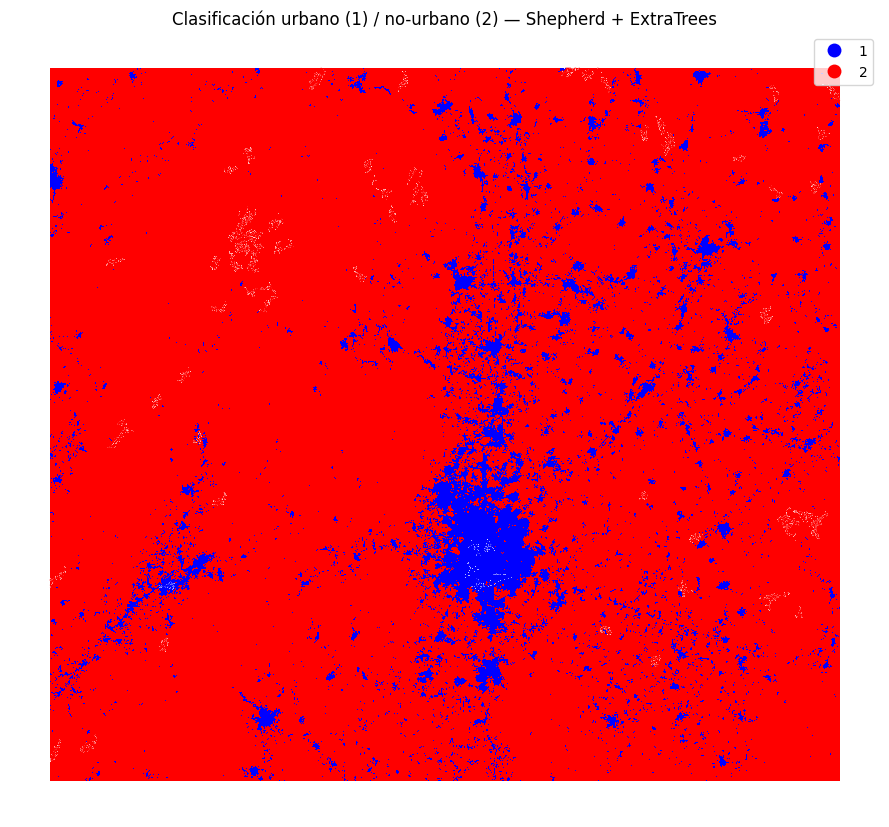

[REPORT] fase7_prediccion: {'segmentos_urbano': 40019, 'segmentos_no_urbano': 405467, 'archivo': 'clasificacion_urbano.gpkg', 'segundos': 74.7}


In [14]:
t0 = time.perf_counter()
feat_cols = [c for c in data.columns if c not in drop_cols]
data["pred"] = pipeline.predict(data[feat_cols])
gdf_clasif = gdf_seg.merge(data[["segment_id","pred"]], on="segment_id", how="left")
gdf_clasif.to_file(CFG["clasif_gpkg"], driver="GPKG")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_clasif.plot(column="pred", categorical=True, cmap="bwr", legend=True, linewidth=0, ax=ax)
ax.set_title("Clasificación urbano (1) / no-urbano (2) — Shepherd + ExtraTrees"); ax.set_axis_off()
plt.tight_layout(); plt.savefig(CFG["fig_mapa"], dpi=120); plt.show()

log_fase("fase7_prediccion",
         segmentos_urbano=int((gdf_clasif.pred==1).sum()),
         segmentos_no_urbano=int((gdf_clasif.pred==2).sum()),
         archivo=CFG["clasif_gpkg"], segundos=round(time.perf_counter()-t0, 1))

## 10. Fase 8 — Generación de reportes (para subir en revisión)

Escribe `reporte_ejecucion.json` (estructurado) y `reporte_ejecucion.md` (legible). **Sube estos dos archivos + las dos figuras** para revisar la corrida sin reejecutar.

In [15]:
# JSON estructurado
with open(CFG["reporte_json"], "w", encoding="utf-8") as f:
    json.dump(REPORT, f, ensure_ascii=False, indent=2)

# Markdown legible
def md_reporte(R):
    L = [f"# Reporte de ejecución — {R['generado']}", ""]
    L += ["## Entorno"] + [f"- **{k}**: {v}" for k, v in R["entorno"].items()] + [""]
    L += ["## Fases", ""]
    for nombre, datos in R["fases"].items():
        L.append(f"### {nombre}")
        for k, v in datos.items():
            if k == "reporte_sklearn": continue       # ya resumido en accuracy/f1
            if k == "matriz_confusion": v = f"`{v}`"
            L.append(f"- **{k}**: {v}")
        L.append("")
    f6 = R["fases"].get("fase6_clasificacion", {})
    if f6:
        L += ["## Resumen del modelo",
              f"- Accuracy: **{f6.get('accuracy')}**",
              f"- F1 urbano: **{f6.get('f1_urbano')}** | F1 no-urbano: **{f6.get('f1_no_urbano')}**",
              f"- Matriz de confusión: `{f6.get('matriz_confusion')}`", ""]
    L += ["## Archivos generados",
          "- segments.gpkg, features_sentinel_urbano.csv, clasificacion_urbano.gpkg",
          "- matriz_confusion.png, mapa_clasificacion.png",
          "- reporte_ejecucion.json, reporte_ejecucion.md"]
    return "\n".join(L)

with open(CFG["reporte_md"], "w", encoding="utf-8") as f:
    f.write(md_reporte(REPORT))

print("Reportes escritos:")
for p in (CFG["reporte_json"], CFG["reporte_md"], CFG["fig_cm"], CFG["fig_mapa"]):
    print(f"  {p}  ->  existe={os.path.exists(p)}")
print("\n--- Vista previa del .md ---\n")
print(md_reporte(REPORT)[:1200])

Reportes escritos:
  reporte_ejecucion.json  ->  existe=True
  reporte_ejecucion.md  ->  existe=True
  matriz_confusion.png  ->  existe=True
  mapa_clasificacion.png  ->  existe=True

--- Vista previa del .md ---

# Reporte de ejecución — 2026-06-09T15:20:42

## Entorno
- **python**: 3.11.15
- **plataforma**: Linux-6.14.0-37-generic-x86_64-with-glibc2.39
- **numpy**: 1.26.4
- **pandas**: 3.0.3
- **rasterio**: 1.4.4
- **geopandas**: 1.1.3

## Fases

### fase0_descarga
- **ts**: 2026-06-09T15:22:20
- **archivos_MB**: {'GM_AGS_2020.tif': 2662.1, '00l.gpkg': 110.4, 'limite_ags.zip': 0.0}
- **limite_shp**: limite_ags/Region_Aguascalientes.shp
- **segundos**: 59.7

### fase1_segmentacion
- **ts**: 2026-06-09T15:34:31
- **dims**: [10005, 11086]
- **bandas**: 12
- **n_segmentos**: 445486
- **n_poligonos**: 445486
- **pequenos_eliminados**: 7623366
- **crs**: PROJCS["unknown",GEOGCS["unknown",DATUM["Unknown_based_on_GRS80_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG",

---
### Reutilización para el cuaderno de **cultivos**
- Cambia **solo la Fase 2** (verdad-terreno de cultivos en vez de localidades urbanas); Fases 1, 3–8 quedan casi idénticas.
- Multiclase: generaliza `klass__N` con un `np.bincount` por cada valor de clase.
- Más features: agrega índices (NDVI, NDBI…) como bandas extra del ráster; entran solos vía `exactextract`.
- `pyshepseg` en `requirements.txt`: `git+https://github.com/ubarsc/pyshepseg.git`

### Nota de fase de desarrollo
Tras correrlo, súbeme `reporte_ejecucion.json` + `reporte_ejecucion.md` + las dos figuras. Con eso reviso segmentación, balance de clases, métricas y tiempos sin reejecutar nada.